# Leer y Escribir archivos

## Texto

Podemos leer y escribir archivos usando la función `open()`

```
open(<ruta>, mode=<modo>, enconding="utf8")
```

existen distintos modos para cargar nuestro archivo, pero veremos estos tres:

* "r" : Solo lectura (read-only)
* "w" : Solo escritura (write-only). **Cuidado!** se sobreescribe todo el archivo!
* "a" : Agregar (append)

el `encoding` "utf8" o "utf-8" es el formato de codificación que nos permite interpretar correctamente texto en español https://es.wikipedia.org/wiki/UTF-8.

Luego de abrir un archivo tenemos que cerrarlo usando el método `.close()`

In [1]:
file = open("salida.txt", "w")
file.write("escribo mi archivo")
file.close()

### Escribir un archivo

Usando el modo de escritura "w" (de *write*) podemos abrir un archivo y escribir sobre él (borrando todo su contenido, CUIDADO!), o crearlo en caso de que no exista

In [2]:
file = open("texto.txt", mode="w", encoding="utf-8")
file.write("Estoy escribiendo una línea!")
file.close()  # cerramos el archivos

Para evitar tener que cerrar el archivo tenemos la sentencia `with`, un tipo de Gestor de Contexto en Python.

In [3]:
with open("texto.txt", mode="w", encoding="utf8") as file:
    # Si quiero escribir varias líneas uso "\n"
    file.write("Línea 1\n")
    file.write("Línea 2\n")
    file.write("Línea 3\n")
    print(file.closed)  # El archivo sigue abierto

print(file.closed)  # El archivo ahora está cerrado

False
True


### Leyendo un Archivo

Para leer un archivo debemos usar el modo lectura "r" (de *read*)

In [4]:
with open("texto.txt", mode="r", encoding="utf8") as file:

    # El método read() lee todo el contenido del archivo:
    texto = file.read()

print(texto)

Línea 1
Línea 2
Línea 3



In [5]:
with open("texto.txt", mode="r", encoding="utf8") as file:

    # El método readline() lee solo una línea.
    linea = file.readline()

print(linea)

Línea 1



In [6]:
with open("texto.txt", mode="r", encoding="utf8") as file:

    # El método readlines() lee todas las lineas y las guarda en una lista
    lineas = file.readlines()

print(lineas)  # una lista con las diferentes lineas

['Línea 1\n', 'Línea 2\n', 'Línea 3\n']


In [7]:
with open("texto.txt", mode="a", encoding="utf8") as file:
    file.write("Una última línea\n")

In [8]:
with open("texto.txt", "r", encoding="utf8") as file:
    texto = file.read()  # todo el archivo como una string
    print(texto)

Línea 1
Línea 2
Línea 3
Una última línea



In [9]:
with open("texto.txt", "r", encoding="utf8") as file:
    for line in file.readlines():
        print(line)  # con end="" evito que print() cree una nueva línea vacía

Línea 1

Línea 2

Línea 3

Una última línea



### Ejercicios:

1) Cómo podemos contar el número de palabras en un texto?
2) Cómo podemos ver cuantas veces se repite una dada palabra?

### Pathlib

Una librería muy útil para moverme entre carpetas y explorar archivos desde python


In [10]:
import pathlib

path = pathlib.Path("")

print(path)
print(path.absolute())

.
/home/atuel/Documents/Sync/1-Areas/Docencia/Metodos Numericos FACET/MN1/2026/intro_python_2026


In [11]:
import pathlib

path = pathlib.Path("")

for file in path.iterdir():
    print(file)

2-clases.ipynb
3-extras-varios.ipynb
sunspots.csv
salida.txt
casas.xlsx
secreto.json
.ipynb_checkpoints
0-intro-python-2026.ipynb
notas.json
COVID19-enero2022.txt
koala.png
1-leer-y-escribir-archivos.ipynb
texto.txt
ejercicios


In [12]:
import pathlib

path = pathlib.Path("")

for file in path.iterdir():
    if file.suffix == ".txt":  # puedo imprimir solo ciertos archivos
        print(file)

salida.txt
COVID19-enero2022.txt
texto.txt


In [13]:
# Puedo crear directorios

nueva_carpeta = path / "nueva_carpeta"
nueva_carpeta.mkdir()  # creo la carpeta

## JSON

JSON es un formato que nace con JavaScript y la web, muy utilizado para compartir información. En python lo podemos utilizar para serializar (guardar) algunos objetos como pueden ser las listas o los diccionarios

In [14]:
import json

lista_muy_importante = ["receta", "super", "secreta"]

with open("secreto.json", "w") as file:
    json.dump(lista_muy_importante, file)

In [15]:
with open("secreto.json", "r") as file:
    lista_leida = json.load(file)

lista_leida.append("hola")
lista_leida

['receta', 'super', 'secreta', 'hola']

In [16]:
notas_de_alumnos = {"Juan": 9, "Victoria": 8, "José": 6}

with open("notas.json", "w", encoding="utf-8") as file:
    json.dump(notas_de_alumnos, file)

In [17]:
with open("notas.json", "r") as file:
    dic = json.load(file)

dic["Blas"] = 5

print(dic)

{'Juan': 9, 'Victoria': 8, 'José': 6, 'Blas': 5}


## Pandas

[Pandas](https://pandas.pydata.org/) es una librería muy popular para trabajar con tablas tipo excel. Esta librería nos ofrece muchas herramientas, pero una de ellas es poder leer y escribir archivos de Excel

In [18]:
import pandas as pd

manchas_solares = pd.read_csv( 
    "sunspots.csv", # el archivo que quiero leer
    index_col=0,    # la primera columna es el índice
    parse_dates=[1], # la segunda columna es la fecha, la parseo como fecha
    )

manchas_solares.head() # ver primeras filas

,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7


<Axes: xlabel='Date'>

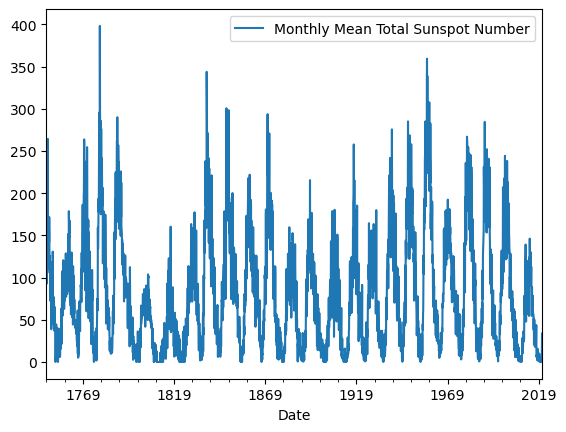

In [19]:
manchas_solares = manchas_solares.set_index("Date")
manchas_solares.plot()

In [20]:
# También puedo crear un excel a partir de un diccionario
casas = {
    "personas": ["harry", "hermione", "ron"],
    "casa": ["Griffindor", "Griffindor", "Griffindor"],
}

# primero creo un DataFrame
casas_df = pd.DataFrame(casas)

# Luego uso el método to_excel()
casas_df.to_excel("casas.xlsx")  # es importante la extensión .xlsx

## Imagenes

Existen librerías como PIL https://pillow.readthedocs.io/en/stable/handbook/tutorial.html que nos permiten manipular imagenes. Veamos un par de ejemplos

In [21]:
from PIL import Image

koala = Image.open(r"koala.png")
koala.show()

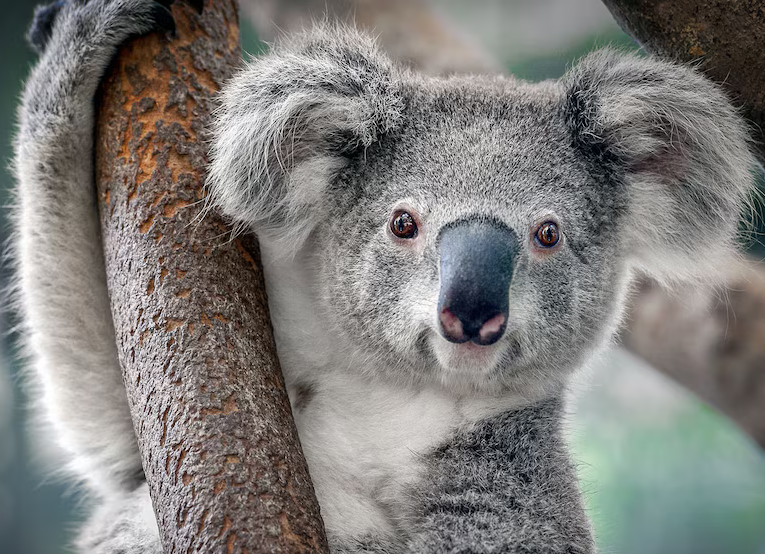

In [22]:
koala

In [23]:
koala.split()

(<PIL.Image.Image image mode=L size=765x554>,
 <PIL.Image.Image image mode=L size=765x554>,
 <PIL.Image.Image image mode=L size=765x554>,
 <PIL.Image.Image image mode=L size=765x554>)

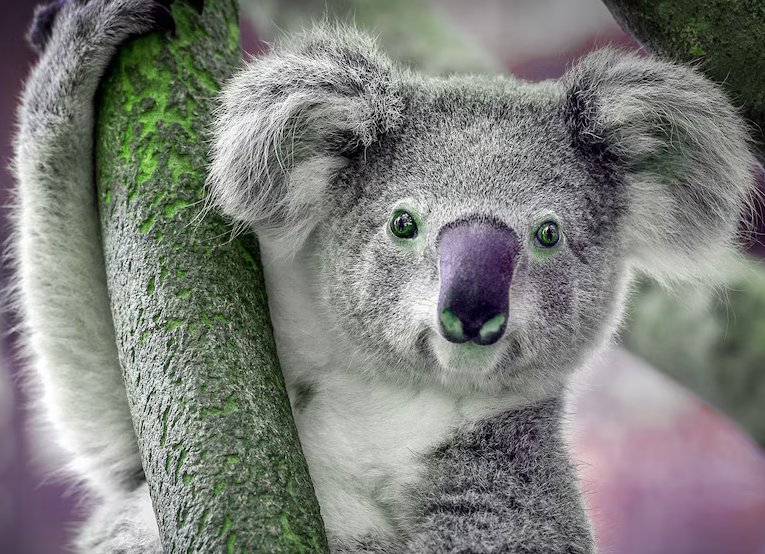

In [24]:
# Puedo separar los canales R G B ALPHA (Rojo, Verde, Azul y Transparencia)
r, g, b, a = koala.split()

# Y puedo colocarlos en otro orden
Image.merge("RGBA", (g, r, b, a))

(765, 554)


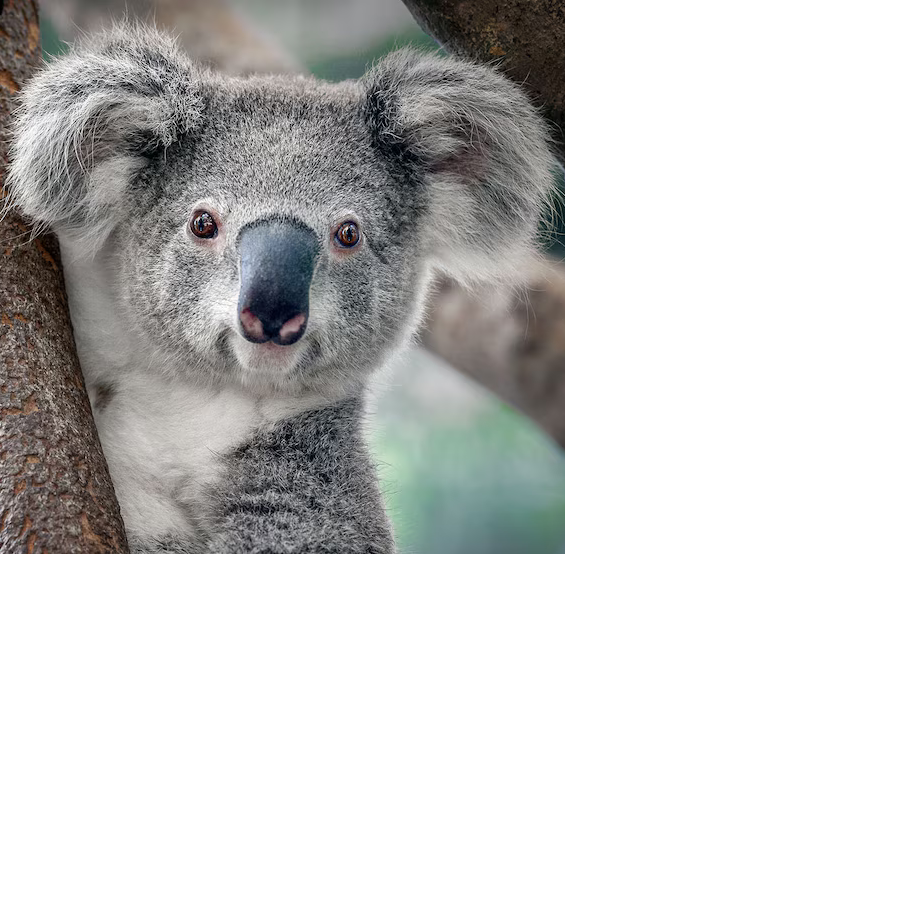

In [35]:
print(koala.size)

# Puedo recortar la imagen
koala_recorte = koala.crop((200, 0, 1100, 900))
koala_recorte

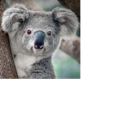

In [36]:
# Puedo cambiar su tamaño
koala_mini = koala_recorte.resize((128, 128))
koala_mini

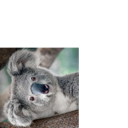

In [37]:
# puedo rotar la imagen
koala_90 = koala_mini.rotate(90)
koala_90